<a href="https://colab.research.google.com/github/jimenami/master_ciencia_datos/blob/main/DATA_MINING/Ensembles/data_mining_7_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://drive.google.com/file/d/17QWv3LToWvm1HBcpP19jpP098gTRn4Bs/view?usp=share_link" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Starting with stacking...

## Previous steps

We import the Python libraries that we will need in this notebook


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from scipy import stats
import random
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.tree import plot_tree

Auxiliary functions to show samples and boundaries. Extracted from https://geoffruddock.com/adaboost-from-scratch-in-python/

In [ ]:
def plot_sample_boundaries(X: np.ndarray,
                  y: np.ndarray,
                  clf=None,
                  sample_weights: Optional[np.ndarray] = None,
                  annotate: bool = False,
                  ax: Optional[mpl.axes.Axes] = None) -> None:
    """ Plot ± samples in 2D, optionally with decision boundary """

    assert set(y) == {-1, 1}, 'Expecting response labels to be ±1'

    if not ax:
        fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
        fig.set_facecolor('white')

    pad = 1
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad

    if sample_weights is not None:
        sizes = np.array(sample_weights) * X.shape[0] * 100
    else:
        sizes = np.ones(shape=X.shape[0]) * 100

    X_pos = X[y == 1]
    sizes_pos = sizes[y == 1]
    ax.scatter(*X_pos.T, s=sizes_pos, marker='+', color='red')

    X_neg = X[y == -1]
    sizes_neg = sizes[y == -1]
    ax.scatter(*X_neg.T, s=sizes_neg, marker='.', c='blue')

    if clf:
        plot_step = 0.01
        xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                             np.arange(y_min, y_max, plot_step))

        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # If all predictions are positive class, adjust color map acordingly
        if list(np.unique(Z)) == [1]:
            fill_colors = ['r']
        else:
            fill_colors = ['b', 'r']

        ax.contourf(xx, yy, Z, colors=fill_colors, alpha=0.2)

    if annotate:
        for i, (x, y) in enumerate(X):
            offset = 0.05
            ax.annotate(f'$x_{i + 1}$', (x + offset, y - offset))

    ax.set_xlim(x_min+0.5, x_max-0.5)
    ax.set_ylim(y_min+0.5, y_max-0.5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

First of all, red wines features from the wine quality dataset are loaded  

In [ ]:
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
wines_red = pd.read_csv(dataset_url, sep=';')
wines_red['type']='red'
wines_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Now, it's the turn for the white wines...

In [ ]:
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
wines_white = pd.read_csv(dataset_url, sep=';')
wines_white['type']='white'
wines_white.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


Finally, we merge both to create the Wine dataset


In [ ]:
wines = pd.concat([wines_red, wines_white],ignore_index=True)
wines.head

<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                    11.0                  34.0  0.99780  3.51       0.56   
1                    25.0                  67.0  0.99680  3.20       0.68   
2                    15.0                  54.0  0.99700  3.26       0.65   
3                    17.0                  60.0  0.99800  3.16       0.58   
4                    11.0                  34.0  0.99780  3.51       0.56   
...                   ...                   ...      ...   ...        ...   
6492                 24.0                  92.0  0.99114  3.27       0.50   
6493                 57.0                 168.0  0.99490  3.15       0.46   
6494                 30.0                 111.0  0.99254  2.99       0.46   
6495                 20.0                 110.0  0.98869  3.34       0.38   
6496                 22.0                  98.0  0.98941  3.26       0.32   

      alcohol  quality   type  
0         9.4        5    red  
1         9.8        5    red  
2         9.8        5    red  
3         9.8        6    red  
4         9.4        5    red  
...       ...      ...    ...  
6492     11.2        6  white  
6493      9.6        5  white  
6494      9.4        6  white  
6495     12.8        7  white  
6496     11.8        6  white  

[6497 rows x 13 columns]>

## Preparing the dataset

We create the *quality_label* based on the quality score according to:

*   Low for less or equal to 5
*   Medium between 6 and 7
*   High for more than 7

Moreover, the *quality_binary* label is created to explain visually the bagging method



In [ ]:
wines['quality_label'] = wines.quality.apply(lambda q: 'low' if q <= 5 else 'medium' if q <= 7 else 'high')
wines['quality_binary'] = wines.quality.apply(lambda q: -1 if q <= 5 else 1 if q > 7 else 0)
wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,low,-1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,low,-1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,low,-1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,medium,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,low,-1


*Nan* data is deleted and number of samples per quality are shown

In [ ]:
wines.dropna().quality_label.value_counts()

,count
quality_label,
medium,3915
low,2384
high,198


In order to conveniently illustrate the techniques, we will proceed to simplify the dataset. For this purpose, we are only interested in samples with high and low wine quality, eliminating those of medium level. In addition, we keep only the *volatile_acidity* and *alcohol* characteristics to form a two-dimensional input space.

<Axes: xlabel='volatile acidity', ylabel='alcohol'>

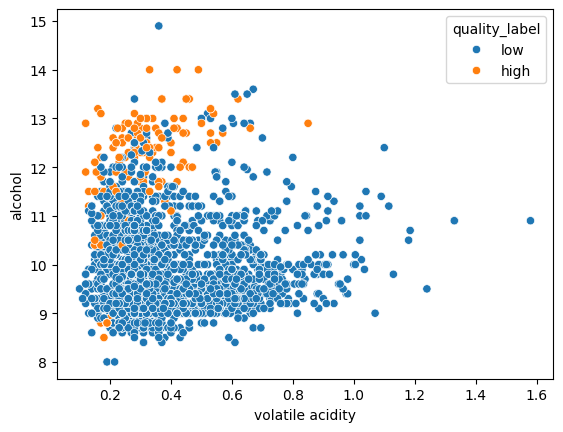

In [ ]:
wines_binary = wines.drop(wines[wines.quality_binary == 0].index)
sns.scatterplot(data=wines_binary,x="volatile acidity",y="alcohol",hue=wines_binary['quality_label'])

Since there are many more low quality samples, we will balance the dataset by keeping very few samples of both.

<ipython-input-9-4480f75718e6>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wines_binary_balanced = g.apply(lambda x: x.sample(int(g.size().min()/5),random_state=9).reset_index(drop=True))


<Axes: xlabel='volatile acidity', ylabel='alcohol'>

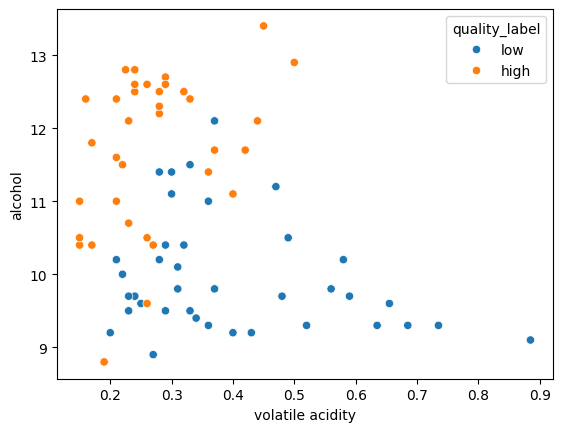

In [ ]:
g = wines_binary.groupby('quality_binary')
wines_binary_balanced = g.apply(lambda x: x.sample(int(g.size().min()/5),random_state=9).reset_index(drop=True))
sns.scatterplot(data=wines_binary_balanced,x="volatile acidity",y="alcohol",hue=wines_binary_balanced['quality_label'])

Finally, we scale the data...

In [ ]:
X=wines_binary_balanced[["volatile acidity", "alcohol"]]
y=wines_binary_balanced['quality_binary'].to_numpy()

sc = StandardScaler()
sc.fit(X)
X_scaled = pd.DataFrame(sc.transform(X),columns = X.columns)

## Very simple with **scikit-learn**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

# define the base models
base_models = list()
base_models.append(('knn', KNeighborsClassifier(n_neighbors=3)))
base_models.append(('cart', DecisionTreeClassifier()))
base_models.append(('svm', SVC()))
base_models.append(('lr', LogisticRegression()))

# define meta learner model
meta_learner = LogisticRegression()

# define the stacking ensemble
stacking = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)


Train error: 3.8%


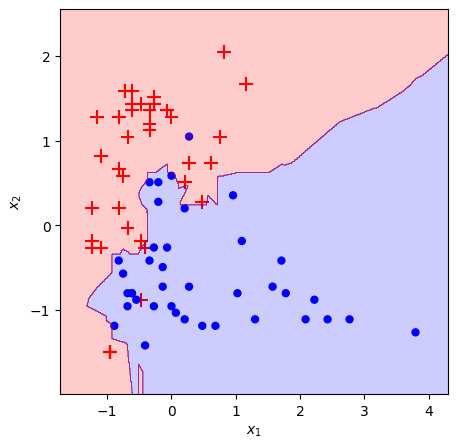

In [ ]:
clf = stacking.fit(X_scaled.to_numpy(), y)
plot_sample_boundaries(X_scaled.to_numpy(), y, clf)

train_err = (clf.predict(X_scaled.to_numpy()) != y).mean()
print(f'Train error: {train_err:.1%}')

# Referencias


*   [Machine Learning in Python: Essential Techniques for Predictive Analysis, Michael Bowles](https://www.wiley.com/en-us/Machine+Learning+in+Python%3A+Essential+Techniques+for+Predictive+Analysis-p-9781118961742)
*   [Wines dataset](https://www.kaggle.com/mgmarques/wines-type-and-quality-classification-exercises)
*   [Functions to show data space and boundaries](https://geoffruddock.com/adaboost-from-scratch-in-python/)